In [1]:
from __future__ import annotations

from typing import Any, Dict, List, Optional
from lxml import html as lxml_html
import json
from pathlib import Path
import re
import hashlib
import os
import random
import requests
import yaml
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

## Support functions
 Start by converting string into float value.

In [2]:
def _to_float(s: Optional[str]) -> Optional[float]:
    if s is None:
        return None
    try:
        return float(s)
    except ValueError:
        return None

Grab the image presented height and width for bounding box measurement reference

In [3]:
def _parse_viewbox(svg_el) -> Optional[Tuple[float, float]]:
    vb = svg_el.get("viewBox")
    if not vb:
        return None
    parts = vb.replace(",", " ").split()
    if len(parts) != 4:
        return None
    w = _to_float(parts[2])
    h = _to_float(parts[3])
    if not w or not h:
        return None
    return (w, h)

Parse the file string input into the desired URI for image and the bounding boxes that come with it.

Receives:
- String to parse
- Optional Category to match case sensitive

Example structure output:
```
Output:
    [
      {
        "src": "<image data-src>",
        "viewbox": (vb_w, vb_h) or None,
        "rects": [{"x":..., "y":..., "w":..., "h":..., "category":"Bus"}, ...]
      },
      ...
    ]
```

In [4]:
_BOX_RE = re.compile(r"box(\d+)$")
_TEXT_RE = re.compile(r"text(\d+)$")

def parse_images_and_rects(
    html_fragment: str,
    category: Optional[str] = None,   # None or "" => all categories
) -> List[Dict[str, Any]]:
    category_filter = (category or "").strip()
    root = lxml_html.fromstring(html_fragment)
    results: List[Dict[str, Any]] = []

    wrappers = root.xpath('.//div[contains(concat(" ", normalize-space(@class), " "), " img-overlay-wrap ")]')

    for wrap in wrappers:
        svg_list = wrap.xpath('.//*[local-name()="svg"]')
        svg = svg_list[0] if svg_list else None

        img_list = wrap.xpath('.//*[local-name()="image"]')
        if not img_list:
            continue

        img = img_list[0]
        src = img.get("xlink:href")  # per your requirement
        if not src:
            continue

        viewbox = _parse_viewbox(svg) if svg is not None else None

        # Map N -> label from <text id="...textN">Label</text>
        label_by_idx: Dict[int, str] = {}
        for t in wrap.xpath('.//*[local-name()="text"]'):
            tid = t.get("id") or ""
            m = _TEXT_RE.search(tid)
            if not m:
                continue
            idx = int(m.group(1))
            label = (t.text or "").strip()
            if label:
                label_by_idx[idx] = label

        rects: List[Dict[str, Any]] = []
        for r in wrap.xpath('.//*[local-name()="rect"]'):
            rid = r.get("id") or ""
            m = _BOX_RE.search(rid)
            idx = int(m.group(1)) if m else None

            rect_label = label_by_idx.get(idx, "") if idx is not None else ""
            if category_filter and rect_label != category_filter:
                continue

            rects.append(
                {
                    "x": _to_float(r.get("x")),
                    "y": _to_float(r.get("y")),
                    "w": _to_float(r.get("width")),
                    "h": _to_float(r.get("height")),
                    "category": rect_label,   # "" if none
                }
            )

        results.append({"src": src, "viewbox": viewbox, "rects": rects})

    return results

In [5]:
html_path = Path("openImagesV7-Bus.md")
html_str = html_path.read_text(encoding="utf-8")

parsed = parse_images_and_rects(html_str, category="Bus")
parsed

[{'src': 'https://live.staticflickr.com/7/6195/6129223344_72d5083329_z.jpg',
  'viewbox': None,
  'rects': [{'x': 70.4,
    'y': 169.8179,
    'w': 259.968,
    'h': 105.76789999999998,
    'category': 'Bus'}]},
 {'src': 'https://live.staticflickr.com/1/74/199649617_9ea9757475_z.jpg?zz=1',
  'viewbox': None,
  'rects': [{'x': 0.0,
    'y': 165.504,
    'w': 118.976,
    'h': 186.48,
    'category': 'Bus'},
   {'x': 97.98400000000001,
    'y': 59.519999999999996,
    'w': 454.016,
    'h': 369.98400000000004,
    'category': 'Bus'}]},
 {'src': 'https://live.staticflickr.com/4/3246/2763277198_ffedf1f4cf_z.jpg',
  'viewbox': None,
  'rects': [{'x': 336.38399999999996,
    'y': 195.216,
    'w': 38.016000000000005,
    'h': 63.6,
    'category': 'Bus'},
   {'x': 345.216,
    'y': 147.21599999999998,
    'w': 173.56799999999998,
    'h': 154.368,
    'category': 'Bus'},
   {'x': 506.81600000000003,
    'y': 177.21599999999998,
    'w': 21.56799999999997,
    'h': 66.768,
    'category': 'Bu

## Lets YOLO out the information

Determine all available classes/categories into a YOLO friendly structure.

In [6]:
def build_class_map(parsed: List[Dict[str, Any]], skip_empty_category: bool = True) -> Dict[str, int]:
    names = sorted({
        r["category"]
        for item in parsed
        for r in item.get("rects", [])
        if (r.get("category") or "").strip()
    })
    return {name: i for i, name in enumerate(names)}

def _sanitize_class_for_filename(name: str) -> str:
    cleaned = re.sub(r"[^A-Za-z0-9]+", "", name)
    return cleaned or "Class"

Handle positional convertion between html and yolo

In [7]:
try:
    from tqdm.auto import tqdm  # nice in notebooks
except Exception:
    tqdm = None


def build_yolo_dataset(
    parsed: List[Dict[str, Any]],
    out_dir: Path,
    train_ratio: float = 0.8,
    seed: int = 42,
    category_filter: Optional[str] = None,
    skip_empty_category: bool = True,
    skip_images_with_no_labels: bool = True,
    show_progress: bool = True,
    start_number: int = 1,  # <-- NEW (inclusive start)
) -> Dict[str, Any]:
    out_dir = Path(out_dir)
    (out_dir / "images" / "train").mkdir(parents=True, exist_ok=True)
    (out_dir / "images" / "val").mkdir(parents=True, exist_ok=True)
    (out_dir / "labels" / "train").mkdir(parents=True, exist_ok=True)
    (out_dir / "labels" / "val").mkdir(parents=True, exist_ok=True)

    cat = (category_filter or "").strip() if category_filter else ""

    # Re-filter (only for class_map) if category_filter given
    parsed_for_map = parsed
    if cat:
        parsed_for_map = []
        for it in parsed:
            rects = [r for r in it.get("rects", []) if (r.get("category") or "").strip() == cat]
            parsed_for_map.append({**it, "rects": rects})

    class_map = build_class_map(parsed_for_map, skip_empty_category=skip_empty_category)

    # Deduplicate by src
    by_src: Dict[str, Dict[str, Any]] = {}
    for it in parsed_for_map:
        src = it["src"]
        if src not in by_src:
            by_src[src] = it
    items = list(by_src.values())

    # Shuffle for randomized split
    rng = random.Random(seed)
    rng.shuffle(items)

    n_total = len(items)
    n_train = int(n_total * train_ratio)

    def _guess_ext_from_url(url: str) -> str:
        lower = url.lower().split("?")[0]
        for ext in (".jpg", ".jpeg", ".png", ".webp"):
            if lower.endswith(ext):
                return ext
        return ".jpg"

    def _download_file(url: str, out_path: Path, timeout: int = 30) -> None:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        with requests.get(url, stream=True, timeout=timeout) as r:
            r.raise_for_status()
            with open(out_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=1024 * 64):
                    if chunk:
                        f.write(chunk)

    def _clip_box_xywh(x: float, y: float, w: float, h: float, W: int, H: int) -> Optional[Tuple[float, float, float, float]]:
        x1 = max(0.0, x)
        y1 = max(0.0, y)
        x2 = min(float(W), x + w)
        y2 = min(float(H), y + h)
        nw = x2 - x1
        nh = y2 - y1
        if nw <= 0 or nh <= 0:
            return None
        return (x1, y1, nw, nh)

    def _xywh_to_yolo(x: float, y: float, w: float, h: float, W: int, H: int) -> Tuple[float, float, float, float]:
        xc = (x + w / 2.0) / W
        yc = (y + h / 2.0) / H
        wn = w / W
        hn = h / H
        xc = min(1.0, max(0.0, xc))
        yc = min(1.0, max(0.0, yc))
        wn = min(1.0, max(0.0, wn))
        hn = min(1.0, max(0.0, hn))
        return (xc, yc, wn, hn)

    def _pick_primary_class_name(it: Dict[str, Any]) -> str:
        """
        Choose filename class name:
        - If category_filter is set => that
        - Else => most frequent class among rects (after skipping empties and unknown classes)
        """
        if cat:
            return cat

        counts: Dict[str, int] = {}
        for r in it.get("rects", []):
            name = (r.get("category") or "").strip()
            if skip_empty_category and not name:
                continue
            if name not in class_map:
                continue
            counts[name] = counts.get(name, 0) + 1

        if not counts:
            return "Class"

        # tie-break: higher count, then lower class_id, then name
        best = sorted(
            counts.items(),
            key=lambda kv: (-kv[1], class_map.get(kv[0], 10**9), kv[0]),
        )[0][0]
        return best

    # Progress + counters
    stats = {
        "downloaded": 0,
        "download_failed": 0,
        "open_failed": 0,
        "no_labels": 0,
        "written": 0,
        "train_written": 0,
        "val_written": 0,
    }

    manifest_items: List[Dict[str, Any]] = []
    counter = int(start_number)

    iterator = enumerate(items)
    use_bar = bool(show_progress and tqdm is not None)
    if use_bar:
        iterator = tqdm(iterator, total=len(items), desc="Building YOLO dataset", unit="img")

    for idx, it in iterator:
        split = "train" if idx < n_train else "val"
        src = it["src"]

        # Determine filename prefix (class name) now
        primary_name = _sanitize_class_for_filename(_pick_primary_class_name(it))
        ext = _guess_ext_from_url(src)

        # Pick a free filename (avoid overwriting if you rerun)
        while True:
            filename = f"{primary_name}{counter:06d}{ext}"   # <-- NO underscore
            img_path = out_dir / "images" / split / filename
            lbl_path = out_dir / "labels" / split / f"{primary_name}{counter:06d}.txt"
            if not img_path.exists() and not lbl_path.exists():
                break
            counter += 1

        # Download
        try:
            _download_file(src, img_path)
            stats["downloaded"] += 1
        except Exception:
            stats["download_failed"] += 1
            if use_bar:
                iterator.set_postfix(stats, refresh=False)
            continue

        # Open image
        try:
            with Image.open(img_path) as im:
                W, H = im.size
        except Exception:
            stats["open_failed"] += 1
            if use_bar:
                iterator.set_postfix(stats, refresh=False)
            continue

        # Scale from SVG viewBox space -> pixels if viewbox exists
        vb = it.get("viewbox")  # (vb_w, vb_h) or None
        vb_w = vb[0] if vb else None
        vb_h = vb[1] if vb else None
        sx = (W / vb_w) if (vb_w and vb_w > 0) else 1.0
        sy = (H / vb_h) if (vb_h and vb_h > 0) else 1.0

        yolo_lines: List[str] = []
        kept_bboxes: List[Dict[str, Any]] = []

        for r in it.get("rects", []):
            name = (r.get("category") or "").strip()

            if skip_empty_category and not name:
                continue
            if cat and name != cat:
                continue
            if name not in class_map:
                continue

            x, y, w, h = r.get("x"), r.get("y"), r.get("w"), r.get("h")
            if None in (x, y, w, h):
                continue

            # Convert to pixel space
            px = float(x) * sx
            py = float(y) * sy
            pw = float(w) * sx
            ph = float(h) * sy

            clipped = _clip_box_xywh(px, py, pw, ph, W, H)
            if not clipped:
                continue
            px, py, pw, ph = clipped

            xc, yc, wn, hn = _xywh_to_yolo(px, py, pw, ph, W, H)
            class_id = class_map[name]
            yolo_lines.append(f"{class_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")

            kept_bboxes.append({"class_id": class_id, "class_name": name, "bbox_xywh_px": [px, py, pw, ph]})

        if skip_images_with_no_labels and len(yolo_lines) == 0:
            stats["no_labels"] += 1
            # remove the downloaded image since we’re skipping it
            try:
                img_path.unlink(missing_ok=True)
            except Exception:
                pass
            if use_bar:
                iterator.set_postfix(stats, refresh=False)
            continue

        # Write labels
        lbl_path.write_text("\n".join(yolo_lines) + ("\n" if yolo_lines else ""), encoding="utf-8")

        stats["written"] += 1
        if split == "train":
            stats["train_written"] += 1
        else:
            stats["val_written"] += 1

        manifest_items.append(
            {
                "split": split,
                "src": src,
                "image_path": str(img_path),
                "labels_path": str(lbl_path),
                "width": W,
                "height": H,
                "bboxes": kept_bboxes,
            }
        )

        counter += 1  # <-- increment only after a successful write

        if use_bar:
            iterator.set_postfix(stats, refresh=False)

    # data.yaml
    names_by_id = {cid: name for name, cid in class_map.items()}
    data_yaml = {
        "path": str(out_dir),
        "train": str(Path("images") / "train"),
        "val": str(Path("images") / "val"),
        "names": names_by_id,
    }
    (out_dir / "data.yaml").write_text(yaml.safe_dump(data_yaml, sort_keys=False), encoding="utf-8")

    return {"out_dir": str(out_dir), "class_map": class_map, "items": manifest_items, "stats": stats}

/opt/homebrew/anaconda3/envs/yolo-meyes/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Create the dataset

In [8]:
dataset = build_yolo_dataset(
    parsed=parsed,
    out_dir=Path("yolo_dataset"),
    train_ratio=0.8,
    seed=42,
    skip_images_with_no_labels=True,   # change to False if you want negatives
)

Building YOLO dataset: 100%|██████████| 1193/1193 [01:59<00:00, 10.01img/s, downloaded=1192, download_failed=1, open_failed=0, no_labels=12, written=1180, train_written=945, val_written=235]


## Show results

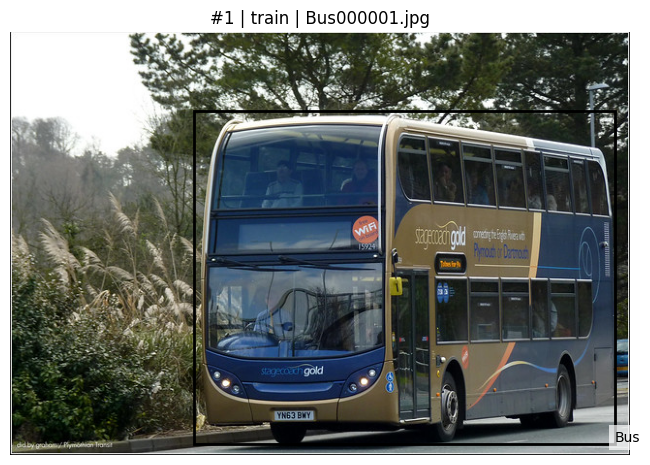

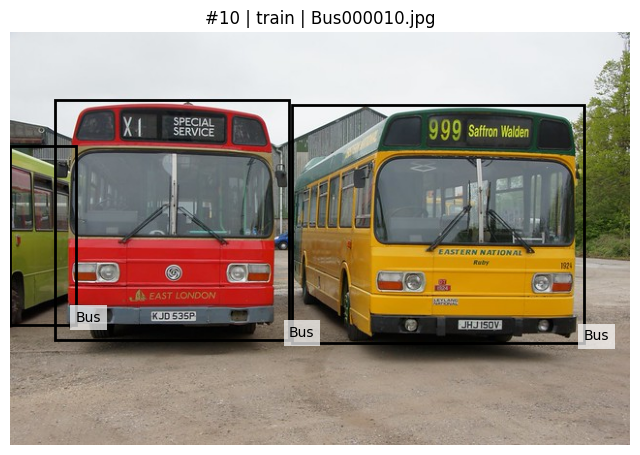

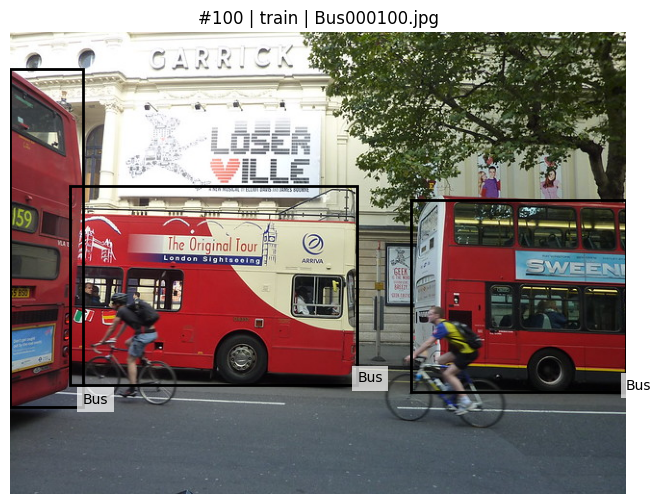

In [9]:
def show_samples(manifest: Dict[str, Any], indices=(0, 9, 99)) -> None:
    items = manifest["items"]
    if not items:
        print("No items to display.")
        return

    for idx in indices:
        if idx >= len(items):
            print(f"Index {idx+1} requested, but only {len(items)} images available.")
            continue

        item = items[idx]
        img_path = item["image_path"]
        bboxes = item["bboxes"]

        with Image.open(img_path) as im:
            fig, ax = plt.subplots(figsize=(8, 6))
            ax.imshow(im)
            ax.set_title(f"#{idx+1} | {item['split']} | {Path(img_path).name}")
            ax.axis("off")

            for bb in bboxes:
                x, y, w, h = bb["bbox_xywh_px"]
                name = bb["class_name"]

                ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=2))
                # "class title at the end" (bottom-right corner of the box)
                ax.text(
                    x + w,
                    y + h,
                    name,
                    fontsize=10,
                    va="bottom",
                    ha="left",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
                )

            plt.show()


show_samples(dataset, indices=(0, 9, 99))